In [1]:
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import imageio
import dill
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import seaborn as sns

from four_room.env import FourRoomsEnv
from four_room.constants import train_config, size
from four_room.wrappers import gym_wrapper
gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

%load_ext autoreload
%autoreload 2

In [2]:
def draw_plots(
    results1: list, 
    results2: list,
    results3: list = None, 
    timesteps: int = int(5e5), 
    val_freq: int = int(1e5),
    q=5
):
    objs1 = []
    for result in results1:
        with open(f'results/dqn_exps/{result}', 'rb') as file:
            temp = dill.load(file)
            objs1.append(temp)        
        
        file.close()
        
    objs2 = []
    for result in results2:
        with open(f'results/dqn_exps/{result}', 'rb') as file:
            temp = dill.load(file)
            objs2.append(temp)        
        
        file.close()
        
    objs3 = []
    if results3:
        for result in results3:
            with open(f'results/dqn_exps/{result}', 'rb') as file:
                temp = dill.load(file)
                temp['reg_test_scores'] = temp['reg_test_scores'][1:]
                temp['lc_curves'] = temp['lc_curves'][1:]
                objs3.append(temp)        
            
            file.close()
        
    plt.style.use('ggplot')
    fig, axs = plt.subplots(2, 2, figsize=(16, 8))
    
    def basic_plot(ax, xs, objs, item, label, color):
        items = []
        for obj in objs:
            items.append(obj[item])
        data = np.array(items)
        mean = np.mean(data, axis=0)
        
        ci_upper = list(np.percentile(data, q=100-q, axis=0))
        ci_lower = list(np.percentile(data, q=q, axis=0))
        
        ax.fill_between(xs, ci_lower, ci_upper, alpha=0.2, color=color)    
        ax.plot(xs, mean, label=label, color=color)
        
        
    # ----------------------- for reg_test_scores -------------------
    xs = np.arange(0, timesteps + val_freq, val_freq)
    xs = np.delete(xs, [0, 1])
    
    basic_plot(axs[0, 0], xs, objs1, 'reg_test_scores', 'Test Env Basic', 'blue')
    basic_plot(axs[0, 0], xs, objs2, 'reg_test_scores', 'Test Env DQN', 'red')
    if results3: basic_plot(axs[0, 0], xs, objs3, 'reg_test_scores', 'Test Env ExploreGo', 'green')
    axs[0, 0].set_title(f"Test Env Scores Comparison")
    axs[0, 0].set_xlabel("Timestep")
    axs[0, 0].set_ylabel("Rewards")
    axs[0, 0].set_ylim(0, 1.0)
    axs[0, 0].legend()
    axs[0, 0].grid(True)
    
    
    # ----------------------- for Uniqueness ---------------------
    
    xs = range(1, timesteps+1)
    
    basic_plot(axs[0, 1], xs, objs1, 'uniqueness', 'Uniqueness Basic', 'blue')
    basic_plot(axs[0, 1], xs, objs2, 'uniqueness', 'Uniqueness DQN', 'red')
    if results3: basic_plot(axs[0, 1], xs, objs3, 'uniqueness', 'Uniqueness ExploreGo', 'green')
    
    axs[0, 1].set_title(f"Uniqueness Comparison")
    axs[0, 1].set_xlabel("Timestep")
    axs[0, 1].set_ylabel("Uniqueness")
    axs[0, 1].set_ylim(0, 1.0)
    axs[0, 1].legend()
    axs[0, 1].grid(True)
    
    
    # ----------------------- LCs  ---------------------
    
    def plot_lcs(ax, xs, objs, label, color):
        lcs = []
        for obj in objs:
            lcs.append(obj['lc_curves'])
        data_lcs = np.array(lcs)
        mean_lcs = np.mean(data_lcs, axis=(0, 1))
        mean_lcs1_axis1 = np.mean(data_lcs, axis=1) # (3, 21)
        ci_upper = list(np.percentile(mean_lcs1_axis1, q=100-q, axis=0))
        ci_lower = list(np.percentile(mean_lcs1_axis1, q=q, axis=0))
        
        ax.fill_between(xs, ci_lower, ci_upper, alpha=0.2, color=color)    
        ax.plot(xs, mean_lcs, label=label, color=color)
    
    xs = np.arange(0, 200000 + 10000, 10000)
    plot_lcs(axs[1, 0], xs, objs1, 'Regression Basic', 'blue')
    plot_lcs(axs[1, 0], xs, objs2, 'Regression DQN', 'red')
    if results3: plot_lcs(axs[1, 0], xs, objs3, 'Regression ExploreGo', 'green')
    axs[1, 0].set_title(f"Validation Regression Score")
    axs[1, 0].set_xlabel("Timestep")
    axs[1, 0].set_ylabel("Rewards")
    axs[1, 0].set_ylim(0, 1.0)
    axs[1, 0].legend()
    axs[1, 0].grid(True)
    
    fig.tight_layout()
    fig.show()
    
    

In [39]:
# draw_plots(
#     ['basic_rnd_seed_0_1000000.pl', 'basic_rnd_seed_1_1000000.pl', 'basic_rnd_seed_2_1000000.pl'],
#     ['rnd_dqn_seed_0_1000000.pl', 'rnd_dqn_seed_1_1000000.pl', 'rnd_dqn_seed_2_1000000.pl']
# )

/tmp/ipykernel_10016/1800510700.py:111: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


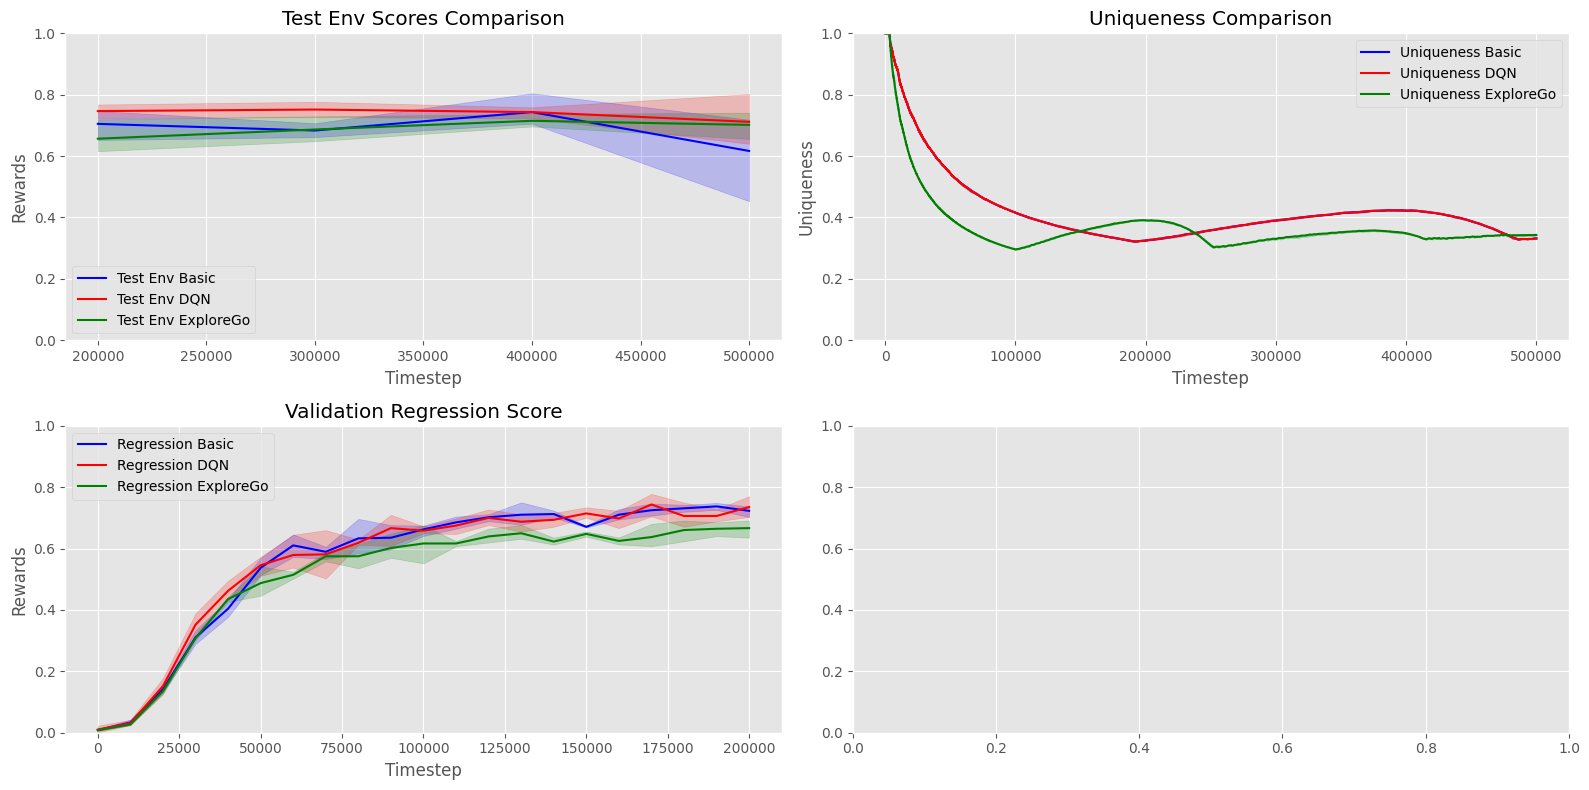

In [55]:
draw_plots(
    ['basic_rnd_exp_05_64_seed_0_500000.pl', 'basic_rnd_exp_05_64_seed_1_500000.pl', 'basic_rnd_exp_05_64_seed_2_500000.pl'],
    ['run_dqn_exp_05_001_64_seed_0_500000.pl', 'run_dqn_exp_05_001_64_seed_1_500000.pl', 'run_dqn_exp_05_001_64_seed_2_500000.pl'],
    ['explorego_seed0_seed_0_500000.pl', 'explorego_seed1_seed_1_500000.pl', 'explorego_seed2_seed_2_500000.pl']
)

## Hyperparameter tuning

In [4]:
def make_table_basic(main_name, hyperparameters, seeds=list([0, 1, 2])):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Batch", int),
        ("test_score_mean", float),
        ("val_score_50", float),
        ("val_score_100", float),
        ("uniqueness_10", float),
        ("uniqueness_50", float),
        ("uniqueness_100", float)
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for bs in hyperparameters[1]:
            temp_objs = []
            for seed in seeds:
                clean_alpha = str(alpha).replace(".", "")
                with open(f'results/dqn_exps/{main_name}_alpha{clean_alpha}_bs{bs}_seed_{seed}_500000.pl', 'rb') as file:
                    temp = dill.load(file)
                    temp_objs.append(temp)
                    
            keys = temp_objs[0].keys()
            averaged = {}
            for k in keys:
                stacked = np.stack([np.array(d[k]) for d in temp_objs])  
                averaged[k] = stacked.mean(axis=0)    
                
            averaged['lc_curves'] = averaged['lc_curves'].mean(axis=0) if len(averaged['lc_curves']) > 0 else [] 
                       
                    
            test_score_avg = averaged['reg_test_scores'].mean() if len(averaged['reg_test_scores']) > 0 else 0.0
            idx_val_50 = int(0.5 * (len(averaged['lc_curves']) - 1)) if len(averaged['lc_curves']) > 0 else 0.0
            val_score_50 = averaged['lc_curves'][idx_val_50] if len(averaged['lc_curves']) > 0 else 0.0
            val_score_end = averaged['lc_curves'][-1] if len(averaged['lc_curves']) > 0 else 0.0
            
            idx_uniq_10 = int(0.1 * (len(averaged['uniqueness']) - 1)) 
            idx_uniq_50 = int(0.5 * (len(averaged['uniqueness']) - 1))
            uniq_10 = averaged['uniqueness'][idx_uniq_10]
            uniq_50 = averaged['uniqueness'][idx_uniq_50]
            uniq_end = averaged['uniqueness'][-1]
            
            data_objs.append(
                Config(alpha, bs, test_score_avg, val_score_50, val_score_end, 
                       uniq_10, uniq_50, uniq_end)
            ) 
            
    return pd.DataFrame(data_objs)

In [4]:
results_basic = make_table_basic('basic_rnd_exp', [(0.5, 1.5, 2.5), (64, 128, 256)])
results_basic

,Alpha,Batch,test_score_mean,val_score_50,val_score_100,uniqueness_10,uniqueness_50,uniqueness_100
0,0.5,64,0.353750,0.370833,0.360417,0.281397,0.110890,0.122220
1,0.5,128,0.338750,0.322917,0.366667,0.278790,0.114583,0.121483
2,0.5,256,0.341250,0.329167,0.325000,0.281140,0.124940,0.114640
3,1.5,64,0.625556,0.580556,0.600000,0.524792,0.214238,0.255607
4,1.5,128,0.628889,0.588889,0.619444,0.515986,0.215140,0.261750
5,1.5,256,0.655556,0.583333,0.652778,0.520880,0.220987,0.260627
6,2.5,64,0.000000,0.000000,0.000000,0.880463,0.644248,0.526756
7,2.5,128,0.000000,0.000000,0.000000,0.882449,0.666479,0.566887
8,2.5,256,0.000000,0.000000,0.000000,0.866661,0.638182,0.528427


In [4]:
with open(f'results/dqn_exps/basic_rnd_exp_alpha05_bs64_seed_0_500000.pl', 'rb') as file:
    results = dill.load(file)

In [19]:
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap

def plot_map(file_name: str, env_ids: int, alpha: float = 0.9):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for i, ax in enumerate(axes.flat):
        heatmap = results['heatmap'][env_ids[i]]
        base_cmap = cm.magma
        colors = base_cmap(np.linspace(0, 1, 256))
        colors[0] = [0, 0, 0, 1]
        new_cmap = ListedColormap(colors)

        norm = Normalize(vmin=np.min(heatmap[heatmap > 0]), vmax=np.max(heatmap))
        nonzero = heatmap[heatmap > 0]
        min_val = np.min(nonzero) if nonzero.size > 0 else 0
        max_val = np.max(heatmap)
        denom = max(max_val - min_val, 1e-8)
        norm_data = np.clip((heatmap - min_val) / denom, 0, 1)

        rgb_array = new_cmap(norm_data)[:, :, :3]
        rgb_array_255 = (rgb_array * 255).astype(int)
        rgb_tuples = np.empty((19, 19), dtype=object)
        for x in range(size):
            for y in range(size):
                rgb_tuples[x, y] = (rgb_array_255[x, y][0], rgb_array_255[x, y][1], rgb_array_255[x, y][2], alpha)
                
        # mask = np.any(rgb_array_255 > 0, axis=2)
        mask = np.ones_like(rgb_tuples, dtype=np.bool)
                
        env.get_wrapper_attr('set_context')(env_ids[i])
        _, _ = env.reset()
        start_pos = env.get_wrapper_attr('start_state')(env_ids[i])
        
        mask[start_pos[0], start_pos[1]] = True
        rgb_tuples[start_pos[0], start_pos[1]] = (np.int64(255), np.int64(0), np.int64(0), alpha)
        image = env.unwrapped.render(
            highlight_mask=mask,
            colors=rgb_tuples, 
            agent_col=(255, 0, 0)
        )
        
        im = ax.imshow(image, cmap=new_cmap, norm=norm)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Counts')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Heatmap Env {env_ids[i]}")

    plt.tight_layout()
    plt.show()

    env.close()

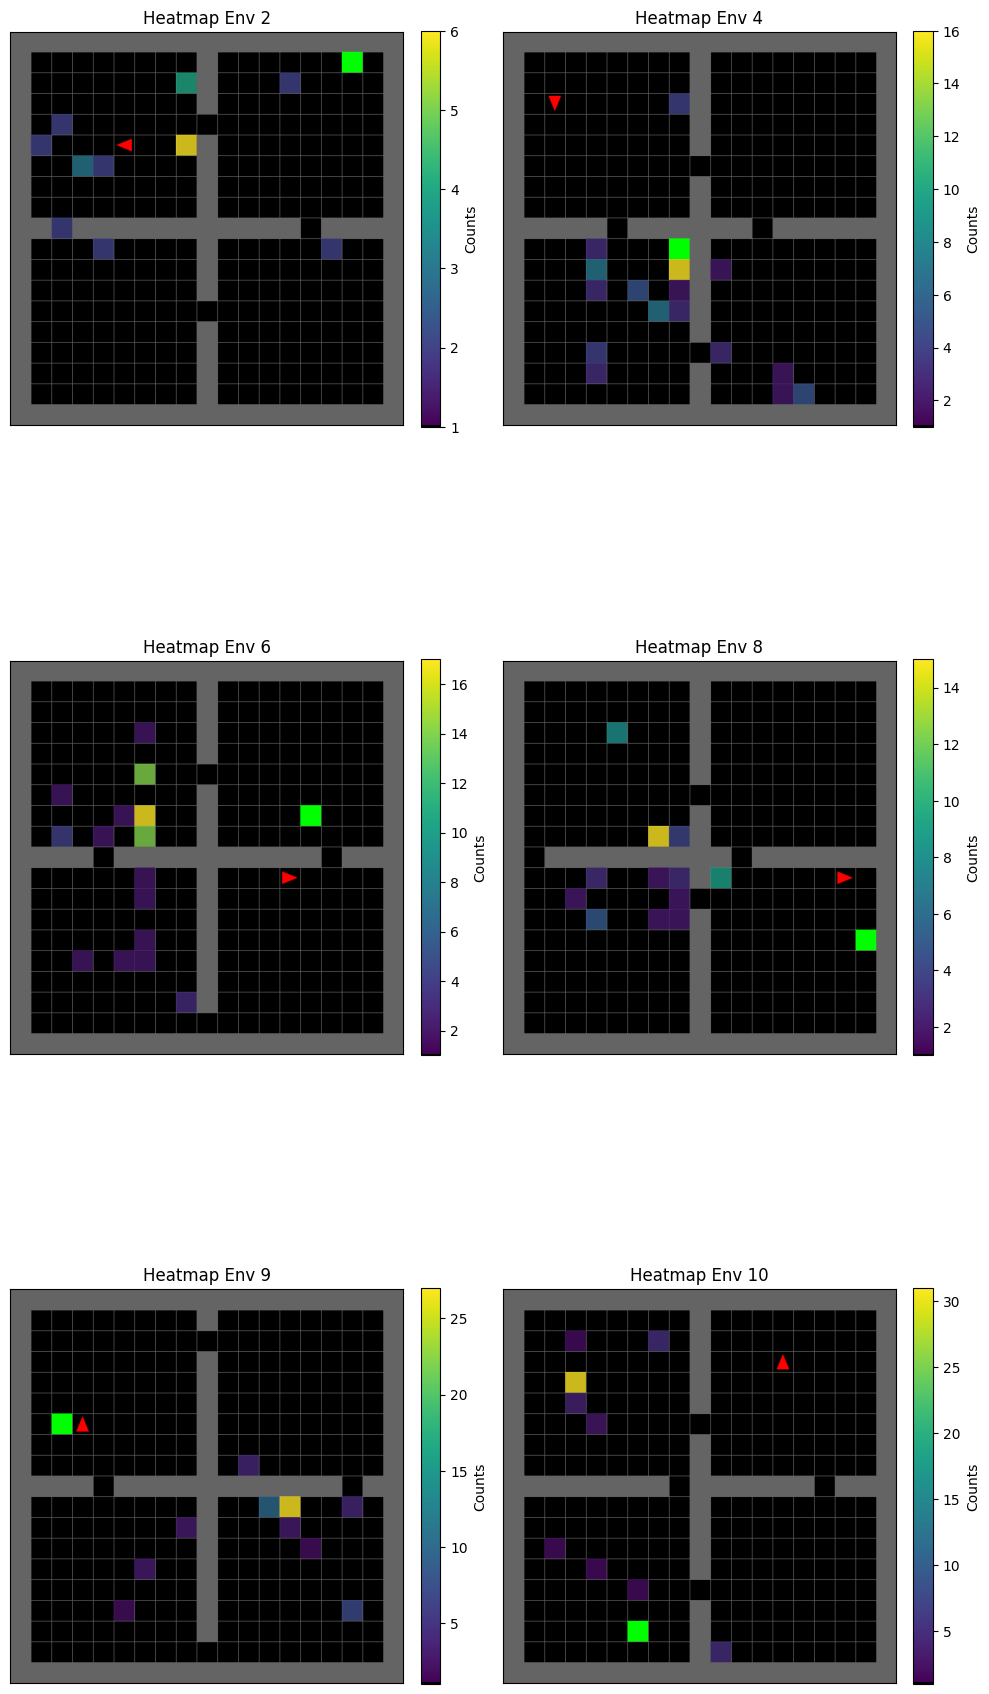

In [61]:
plot_map('basic_rnd_exp_alpha15_bs256_seed_1_500000', [2, 4, 6, 8, 9, 10], alpha=0.8)

In [6]:
def make_table_dqn(main_name, hyperparameters, seeds=list([0, 1, 2])):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("Batch", int),
        ("LR", float),
        ("test_score_mean", float),
        ("val_score_50", float),
        ("val_score_100", float),
        ("uniqueness_10", float),
        ("uniqueness_50", float),
        ("uniqueness_100", float)
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        for bs in hyperparameters[1]:
            for lr in hyperparameters[2]:
                temp_objs = []
                for seed in seeds:
                    clean_alpha = str(alpha).replace(".", "")
                    clean_lr = str(lr).replace(".", "")
                    with open(f'results/dqn_exps/{main_name}_alpha{clean_alpha}_{clean_lr}_bs{bs}_seed_{seed}_500000.pl', 'rb') as file:
                        temp = dill.load(file)
                        temp_objs.append(temp)
                    
                keys = temp_objs[0].keys()
                averaged = {}
                for k in keys:
                    sizes = [len(d[k]) for d in temp_objs]
                    min_size = min(sizes)
                    if min_size != 0:
                        stacked = np.stack([np.array(d[k])[-min_size:] for d in temp_objs]) 
                        averaged[k] = stacked.mean(axis=0)  
                    else: 
                        for d in temp_objs:
                            if len(d[k]) > 0:
                                stacked = np.array(d[k])
                            else:
                                stacked = np.zeros((21, 10))
                        averaged[k] = stacked
                       
                    
                averaged['lc_curves'] = averaged['lc_curves'].mean(axis=0) if len(averaged['lc_curves']) > 0 else [] 
                       
                    
                test_score_avg = averaged['reg_test_scores'].mean() if len(averaged['reg_test_scores']) > 0 else 0.0
                idx_val_50 = int(0.5 * (len(averaged['lc_curves']) - 1)) if len(averaged['lc_curves']) > 0 else 0.0
                val_score_50 = averaged['lc_curves'][idx_val_50] if len(averaged['lc_curves']) > 0 else 0.0
                val_score_end = averaged['lc_curves'][-1] if len(averaged['lc_curves']) > 0 else 0.0
                
                idx_uniq_10 = int(0.1 * (len(averaged['uniqueness']) - 1)) 
                idx_uniq_50 = int(0.5 * (len(averaged['uniqueness']) - 1))
                uniq_10 = averaged['uniqueness'][idx_uniq_10]
                uniq_50 = averaged['uniqueness'][idx_uniq_50]
                uniq_end = averaged['uniqueness'][-1]
                
                data_objs.append(
                    Config(alpha, bs, lr, test_score_avg, val_score_50, val_score_end, 
                        uniq_10, uniq_50, uniq_end)
                ) 
            
    return pd.DataFrame(data_objs)

In [94]:
make_table_dqn('run_dqn_exp', hyperparameters=[(0.5, 1.5, 2.5), (64, 128, 256), (0.01, 0.001, 0.0001)])

,Alpha,Batch,LR,test_score_mean,val_score_50,val_score_100,uniqueness_10,uniqueness_50,uniqueness_100
0,0.5,64,0.0100,0.162778,0.130556,0.144444,0.283168,0.078440,0.076397
1,0.5,64,0.0010,0.515833,0.452083,0.527083,0.346181,0.139253,0.192087
2,0.5,64,0.0001,0.502500,0.475000,0.500000,0.352836,0.143757,0.191607
3,0.5,128,0.0100,0.141667,0.138889,0.186111,0.291787,0.076263,0.074560
4,0.5,128,0.0010,0.470000,0.420833,0.445833,0.342873,0.137743,0.189733
5,0.5,128,0.0001,0.513333,0.414583,0.491667,0.351375,0.144633,0.192237
6,0.5,256,0.0100,0.135556,0.144444,0.150000,0.276427,0.076957,0.076140
7,0.5,256,0.0010,0.490833,0.408333,0.462500,0.346767,0.134740,0.189170
8,0.5,256,0.0001,0.495833,0.445833,0.487500,0.352184,0.143330,0.189983
9,1.5,64,0.0100,0.000000,0.000000,0.000000,0.498129,0.221351,0.149434


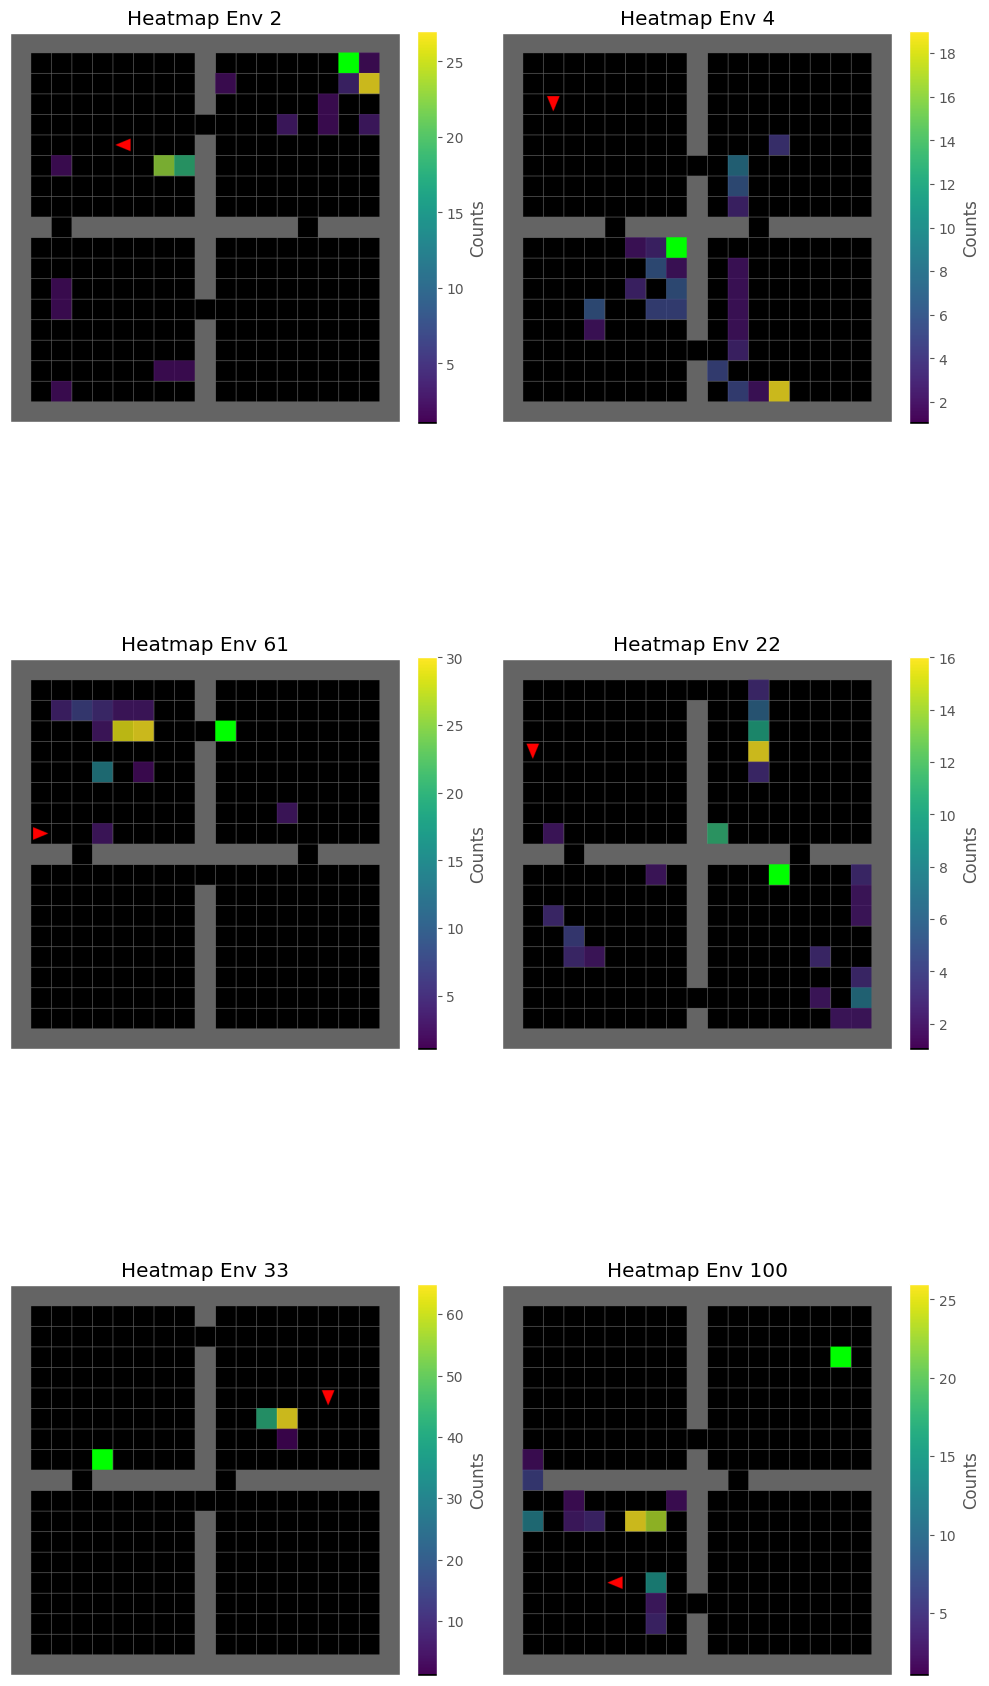

In [98]:
plot_map('run_dqn_exp_alpha05_00001_bs256_seed_1_500000', [2, 4, 61, 22, 33, 100], alpha=0.8)

In [9]:
def make_table_count(main_name, hyperparameters, seeds=list([0, 1, 2])):
    Config = make_dataclass("Config", [
        ("Alpha", float),
        ("test_score_mean", float),
        ("val_score_50", float),
        ("val_score_100", float),
        ("uniqueness_10", float),
        ("uniqueness_50", float),
        ("uniqueness_100", float)
    ])
    
    data_objs = []
    for alpha in hyperparameters[0]:
        temp_objs = []
        for seed in seeds:
            clean_alpha = str(alpha).replace(".", "")
            with open(f'results/dqn_exps/{main_name}_{clean_alpha}_seed_{seed}_500000.pl', 'rb') as file:
                temp = dill.load(file)
                temp_objs.append(temp)
            
        keys = temp_objs[0].keys()
        averaged = {}
        for k in keys:
            sizes = [len(d[k]) for d in temp_objs]
            min_size = min(sizes)
            if min_size != 0:
                stacked = np.stack([np.array(d[k])[-min_size:] for d in temp_objs]) 
                averaged[k] = stacked.mean(axis=0)  
            else: 
                for d in temp_objs:
                    if len(d[k]) > 0:
                        stacked = np.array(d[k])
                    else:
                        stacked = np.zeros((21, 10))
                averaged[k] = stacked
                
            
        averaged['lc_curves'] = averaged['lc_curves'].mean(axis=0) if len(averaged['lc_curves']) > 0 else [] 
                
            
        test_score_avg = averaged['reg_test_scores'].mean() if len(averaged['reg_test_scores']) > 0 else 0.0
        idx_val_50 = int(0.5 * (len(averaged['lc_curves']) - 1)) if len(averaged['lc_curves']) > 0 else 0.0
        val_score_50 = averaged['lc_curves'][idx_val_50] if len(averaged['lc_curves']) > 0 else 0.0
        val_score_end = averaged['lc_curves'][-1] if len(averaged['lc_curves']) > 0 else 0.0
        
        idx_uniq_10 = int(0.1 * (len(averaged['uniqueness']) - 1)) 
        idx_uniq_50 = int(0.5 * (len(averaged['uniqueness']) - 1))
        uniq_10 = averaged['uniqueness'][idx_uniq_10]
        uniq_50 = averaged['uniqueness'][idx_uniq_50]
        uniq_end = averaged['uniqueness'][-1]
        
        data_objs.append(
            Config(alpha, test_score_avg, val_score_50, val_score_end, 
                uniq_10, uniq_50, uniq_end)
        ) 
            
    return pd.DataFrame(data_objs)

In [11]:
make_table_count('run_dqn_exp_count', [(0.5, 1.0, 1.5)])

,Alpha,test_score_mean,val_score_50,val_score_100,uniqueness_10,uniqueness_50,uniqueness_100
0,0.5,0.150000,0.120833,0.145833,0.188166,0.090933,0.073507
1,1.0,0.175000,0.127083,0.127083,0.246041,0.110733,0.087950
2,1.5,0.146111,0.116667,0.113889,0.333832,0.122873,0.125427


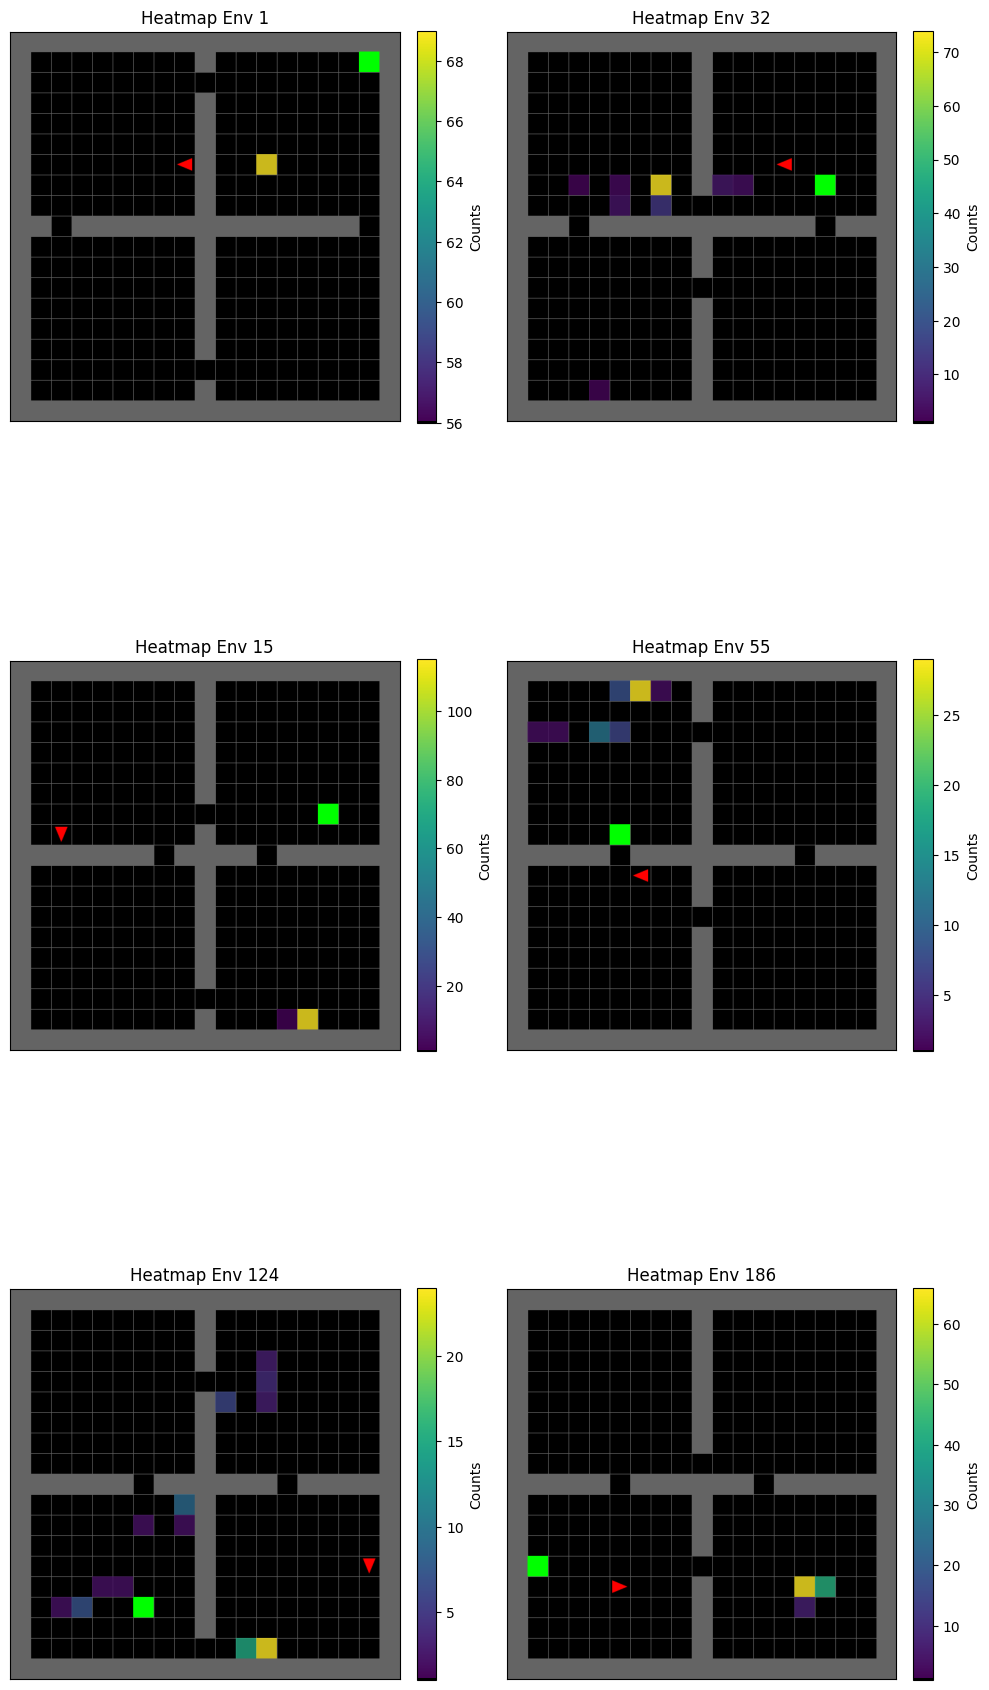

In [19]:
plot_map('run_dqn_exp_count_05_seed_1_500000', [1, 32, 15, 55, 124, 186], alpha=0.8)

In [18]:
make_table_count('run_dqn_exp_v2', [(0.5, 1.0, 1.5)])

,Alpha,test_score_mean,val_score_50,val_score_100,uniqueness_10,uniqueness_50,uniqueness_100
0,0.5,0.430556,0.352778,0.386111,0.364537,0.144198,0.162197
1,1.0,0.428333,0.450000,0.400000,0.505834,0.203253,0.141393
2,1.5,0.000000,0.000000,0.000000,0.756074,0.376294,0.242965


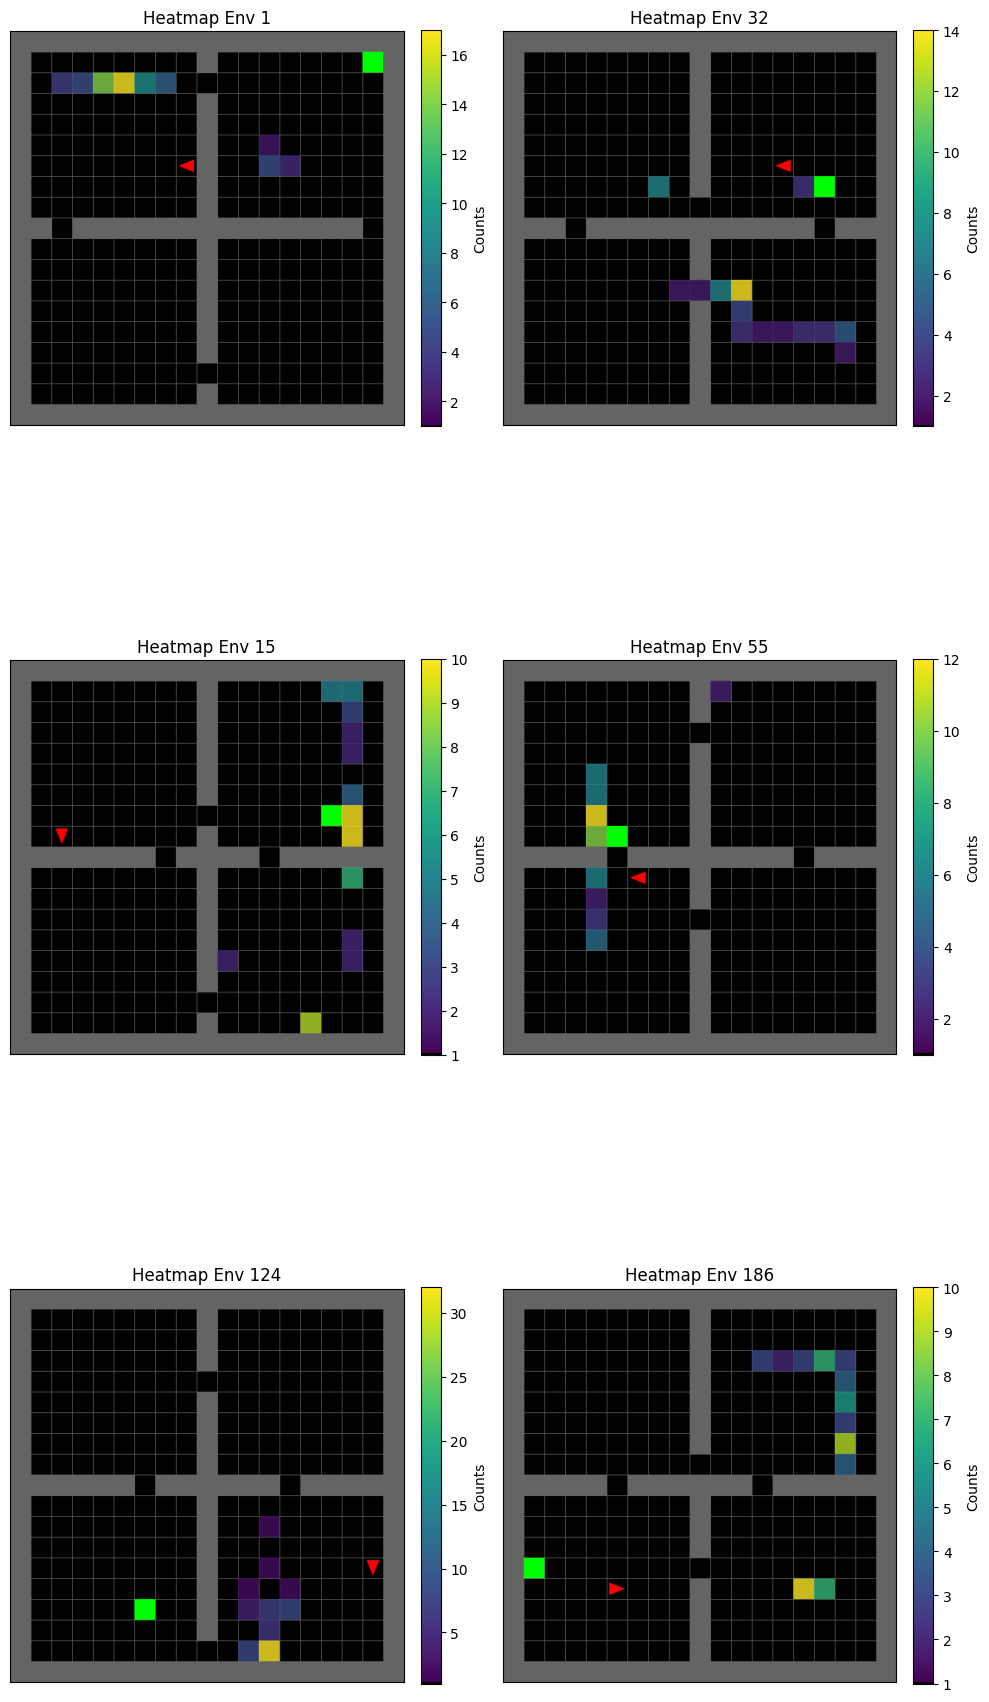

In [22]:
plot_map('run_dqn_exp_v2_10_seed_0_intermediate', [1, 32, 15, 55, 124, 186], alpha=0.8)

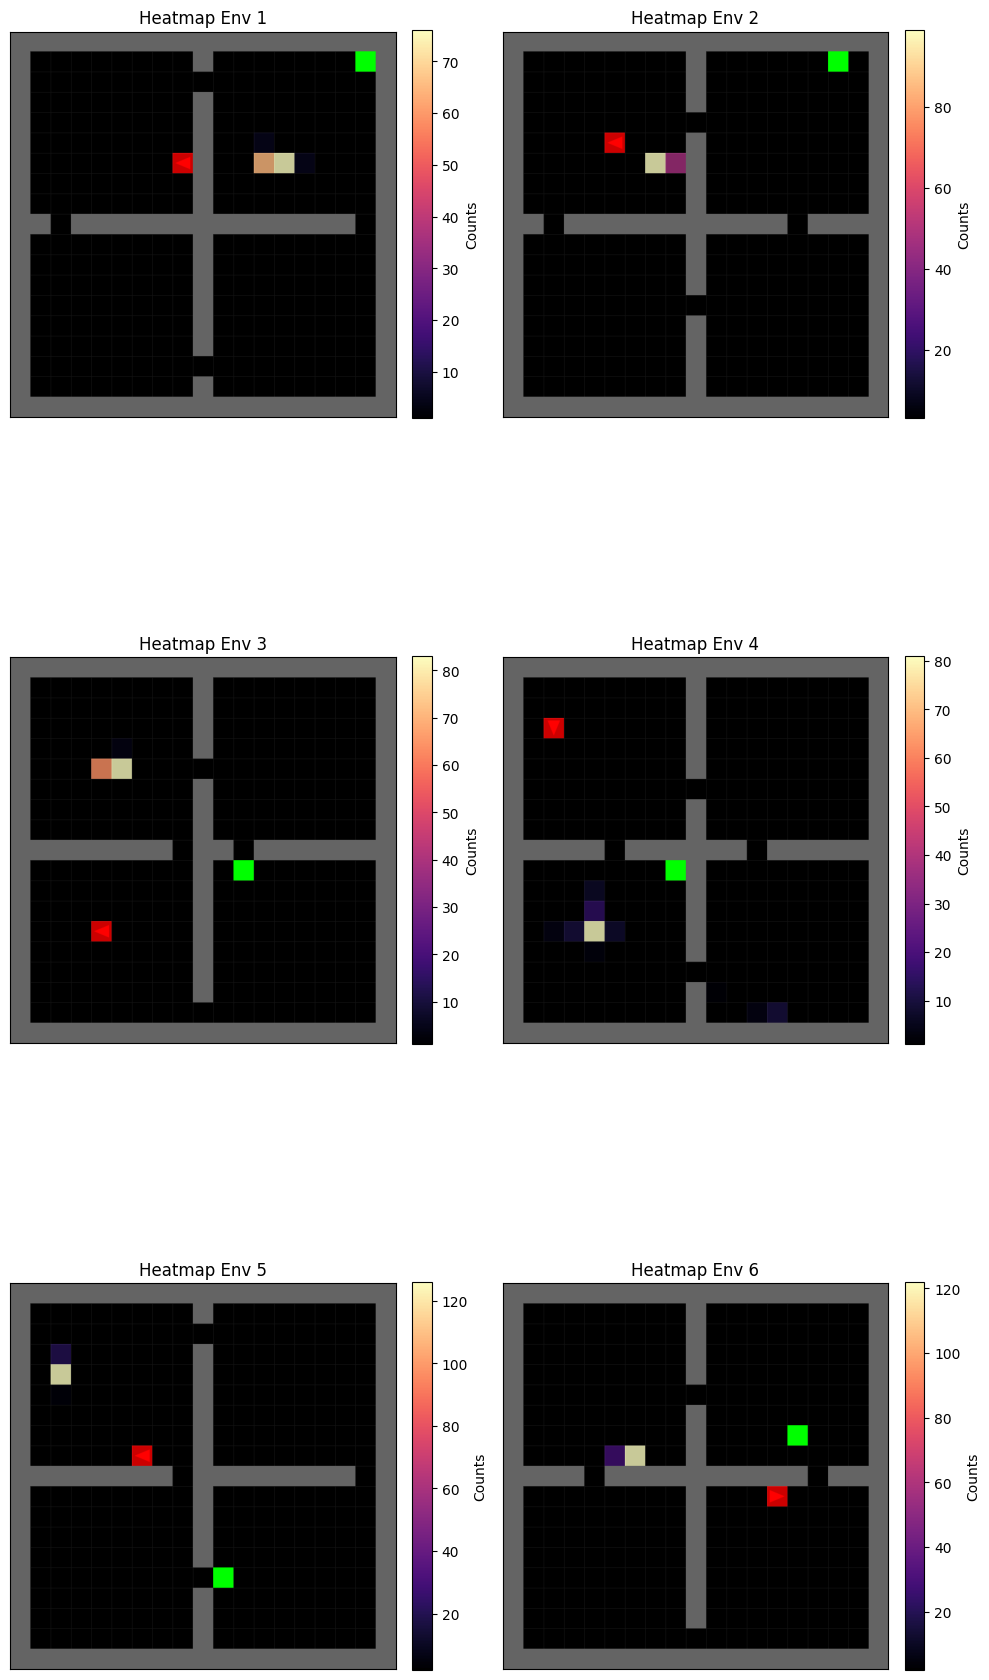

In [20]:
plot_map('basic_count_seed_0_500000', [1, 2, 3, 4, 5, 6], alpha=0.8)

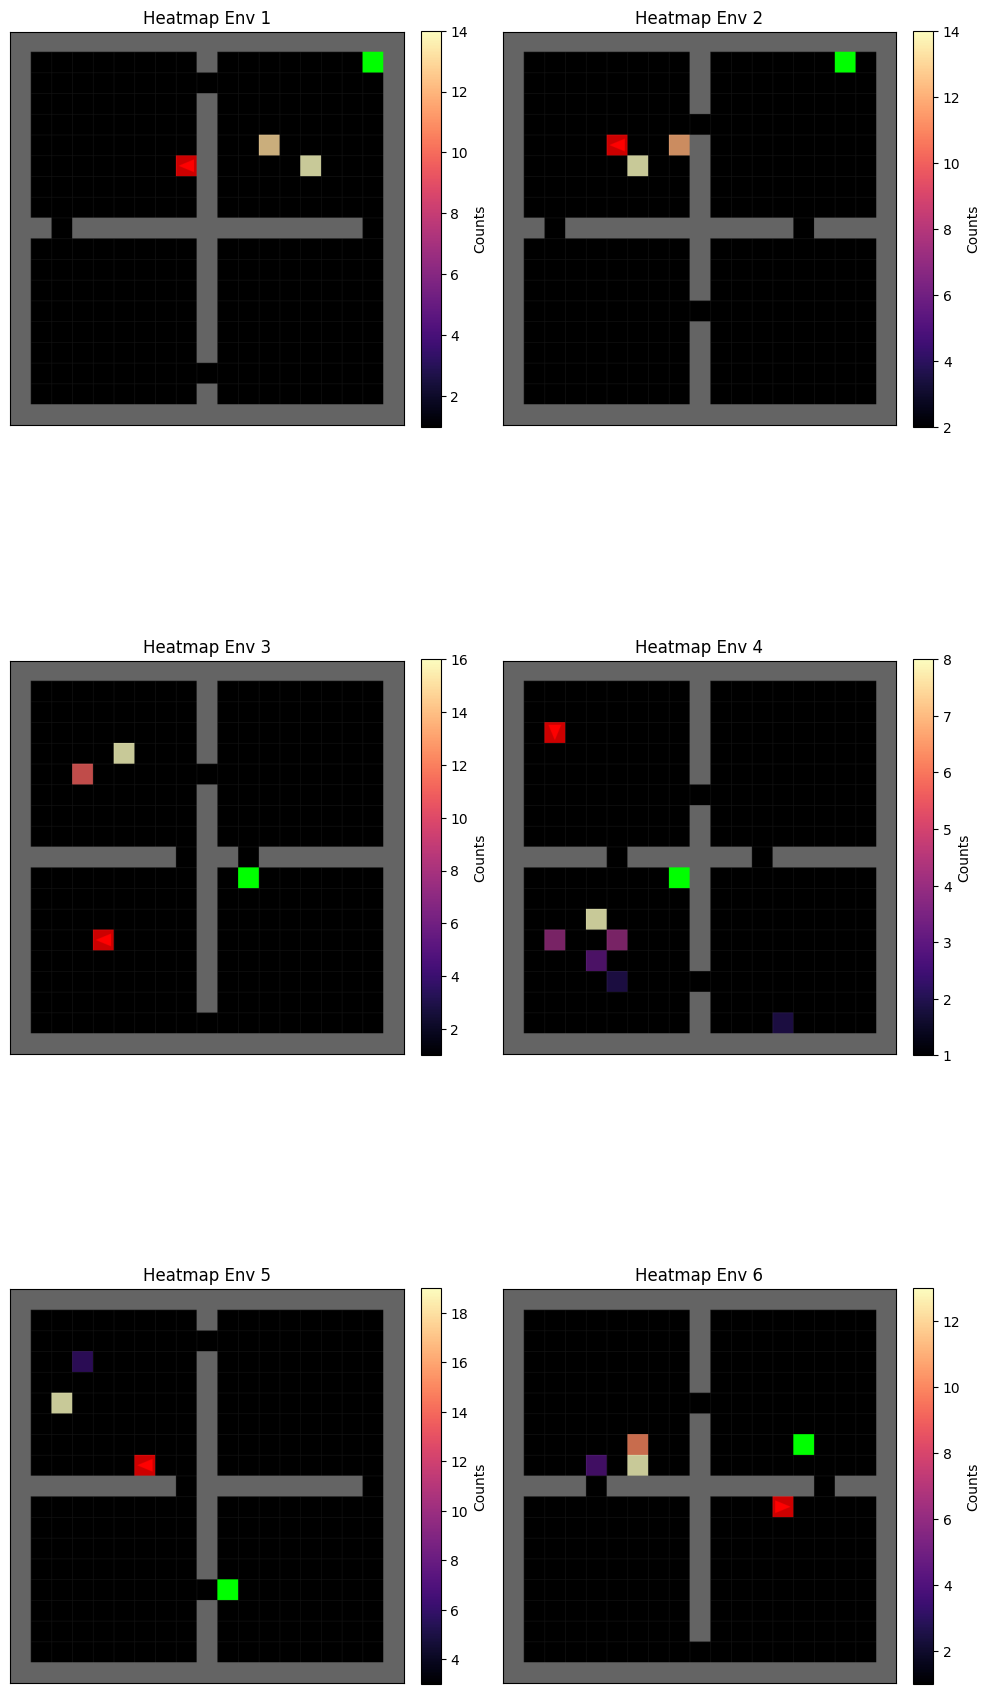

In [24]:
plot_map('basic_count_fixed_seed_0_100000', [1, 2, 3, 4, 5, 6], alpha=0.8)

In [108]:
from copy import deepcopy

def plot_map_new(file_name: str, env_ids: int, alpha: float = 0.9):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for idx, ax in enumerate(axes.flat):
        matrix = results['heatmap'][env_ids[idx]]
        colors = np.full((19, 19), np.nan, dtype=float)

        colors[0, :] = 0
        colors[-1, :] = 0
        colors[:, 0] = 0
        colors[:, -1] = 0

        colors[9, :] = 0
        colors[:, 9] = 0
        
        env.get_wrapper_attr('set_context')(env_ids[idx])
        _, _ = env.reset()
        start_pos, doors_pos, goal_pos = env.get_wrapper_attr('context_info')(env_ids[idx])
        
        room_w = 19//2
        room_h = 19//2
        
        highlight_cells = []
        for j in range(0, 2):
            for i in range(0, 2):
                xL = i * room_w
                yT = j * room_h
                xR = xL + room_w
                yB = yT + room_h

                if i + 1 < 2:
                    pos = (xR, yT + 1 + doors_pos[j])
                    highlight_cells.append(pos)

                if j + 1 < 2:
                    pos = (xL + 1 + doors_pos[2 + i], yB)
                    highlight_cells.append(pos)
        
        colors[start_pos[0], start_pos[1]] = 1
        colors[goal_pos[0], goal_pos[1]] = 2

        for r, c in highlight_cells:
            colors[r, c] = np.nan

        matrix_data = deepcopy(matrix).astype(str)
        for r in range(matrix_data.shape[0]):
            for c in range(matrix_data.shape[1]):
                matrix_data[r, c] = str(int(matrix[r, c]))
                
        matrix_data[start_pos[0], start_pos[1]] = 'Start'
        matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'
        
        sns.heatmap(matrix, cmap='magma', annot=matrix_data, cbar_kws={'label': 'Number of switches'}, ax=ax, fmt='')

        overlay_cmap = sns.color_palette(["grey", "red", "lime"])
        sns.heatmap(colors, cmap=overlay_cmap, mask=np.isnan(colors), cbar=False, alpha=0.6, ax=ax)
        ax.set_title(f"Heatmap Env {env_ids[idx]}")

    plt.tight_layout()
    plt.show()

    env.close()

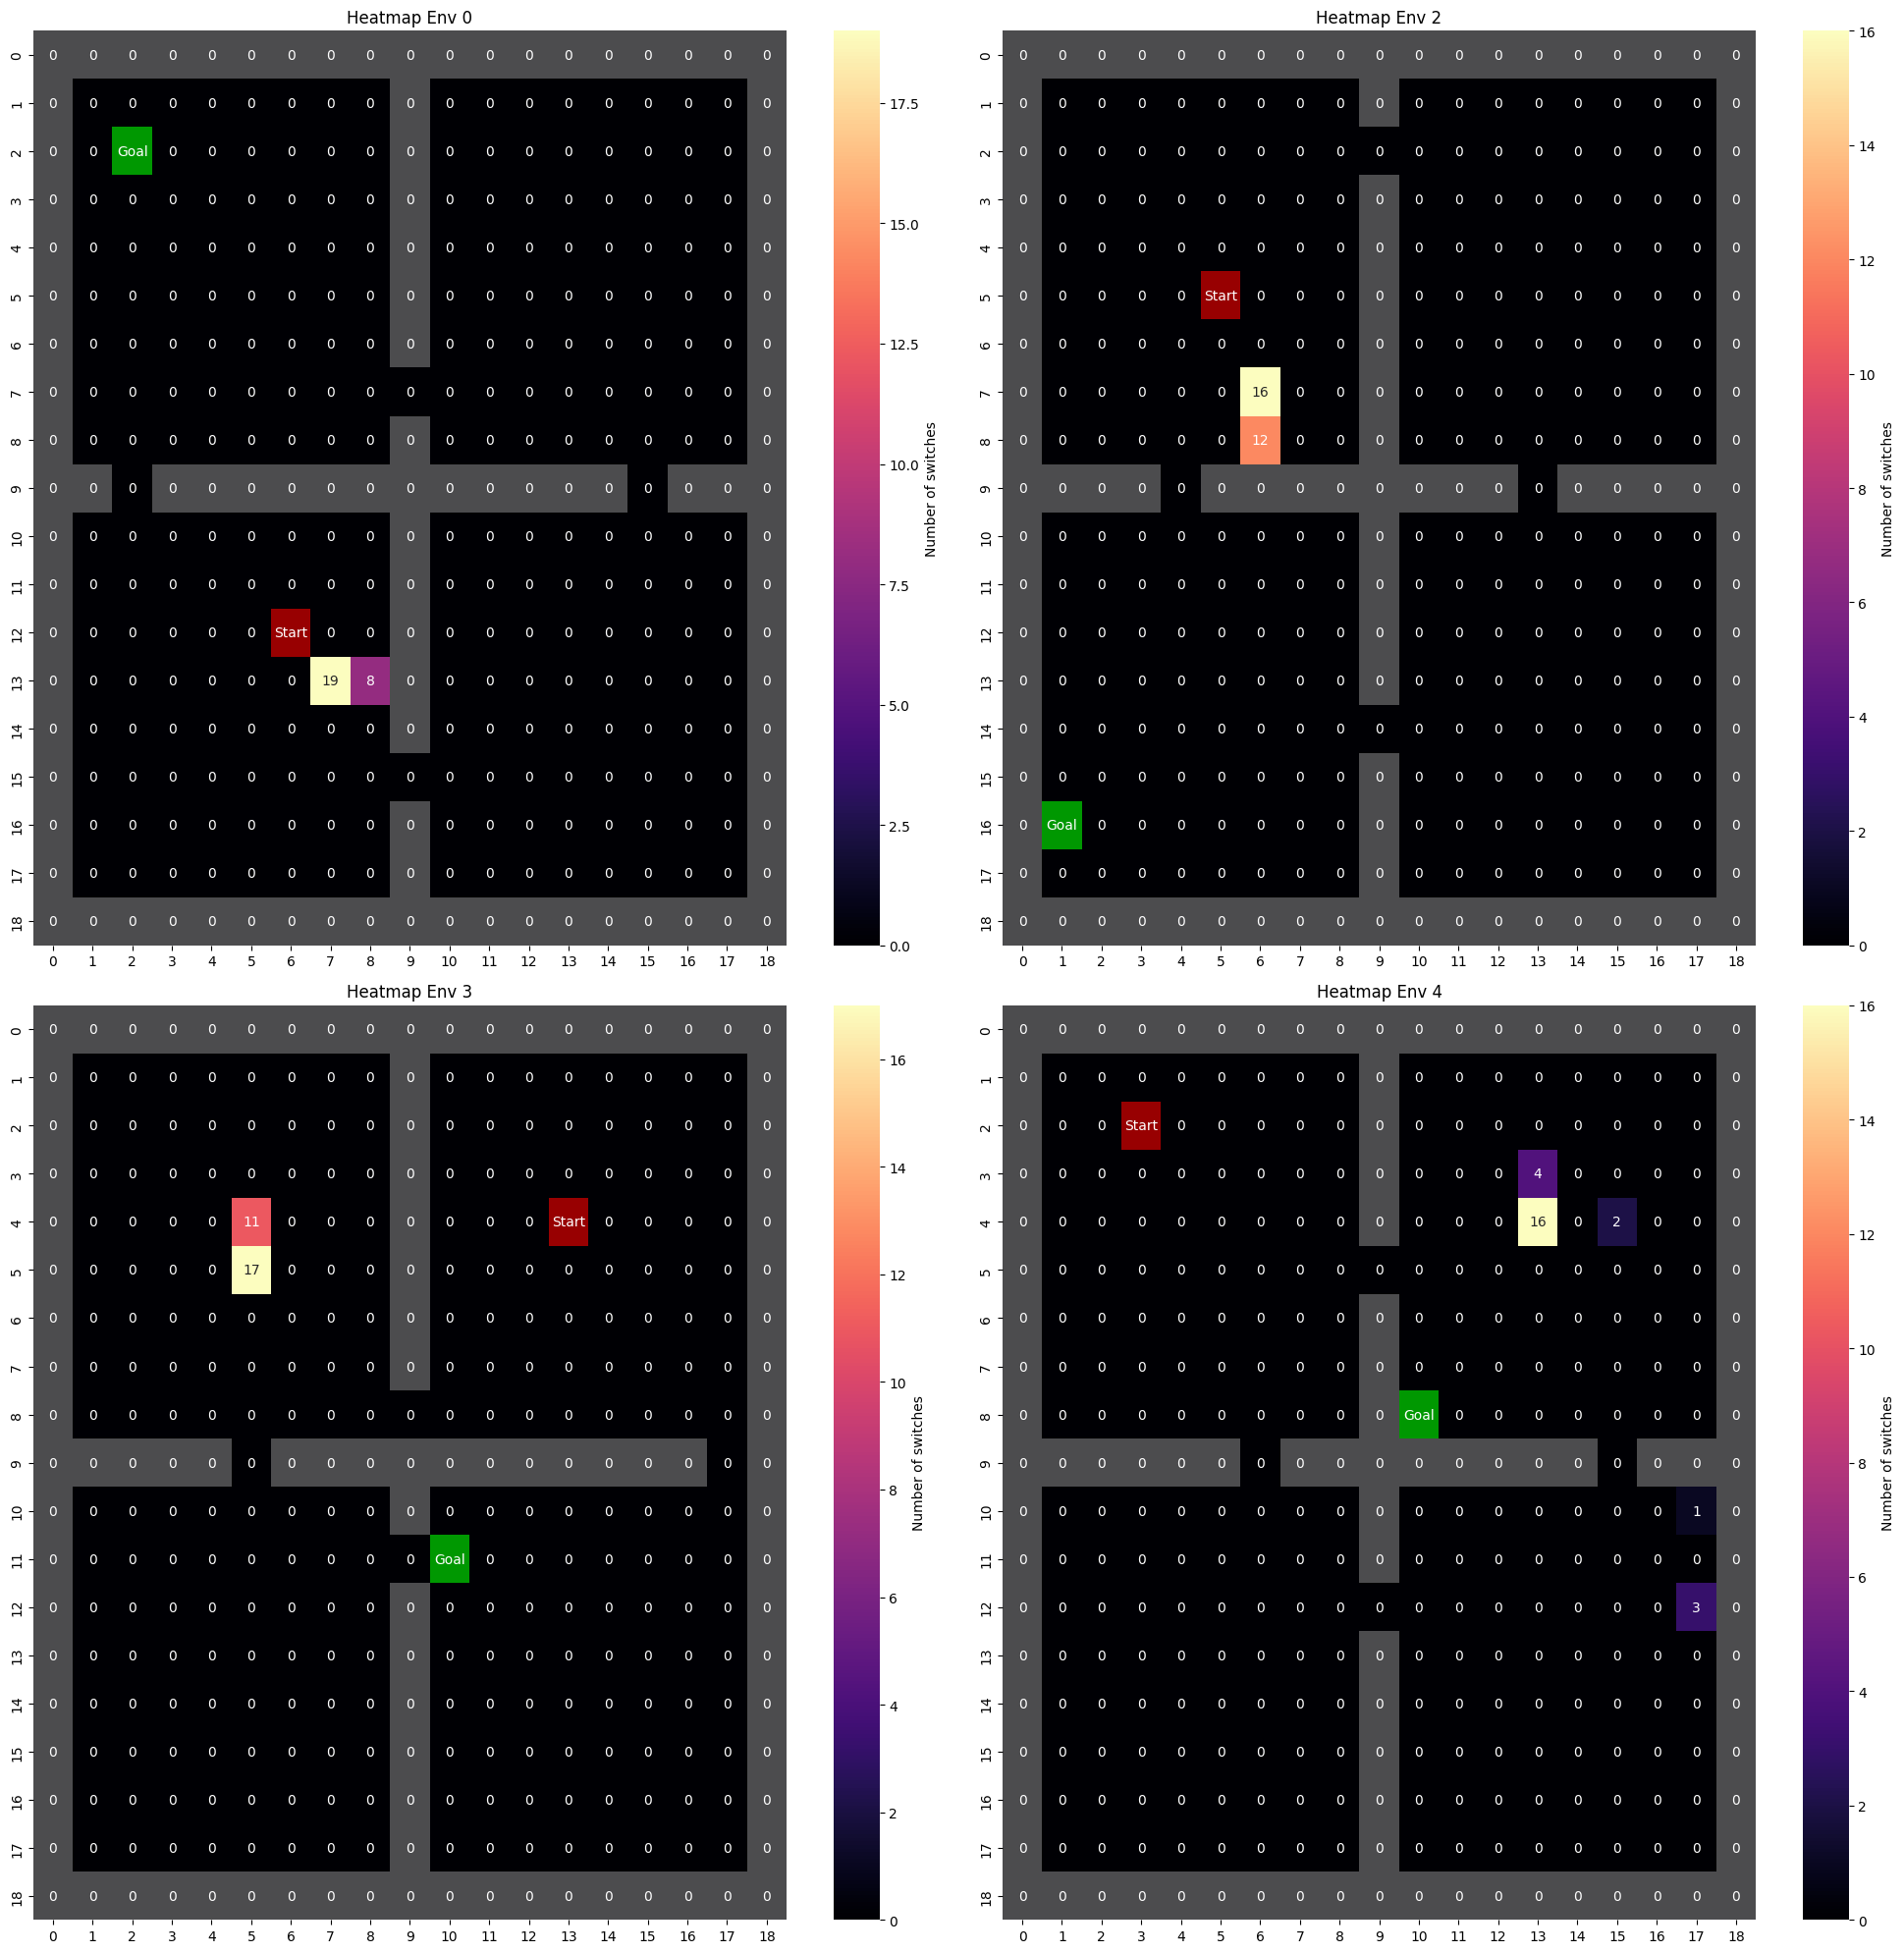

In [109]:
plot_map_new('basic_count_fixed_seed_0_100000', [0, 2, 3, 4])